In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


q1

In [1]:
from pathlib import Path
import numpy as np
from ecg5000_hmad import (
    extract_features, fit_hmad, fit_ocsvm, fixed_contamination_cohorts,
    load_ecg5000, metrics_from_scores, score_hmad, score_ocsvm,
)

PROJECT_ROOT = Path.cwd()
PLOTS_DIR = PROJECT_ROOT / "Plots"
PLOTS_DIR.mkdir(exist_ok=True)
X_train, X_test, y_test, y_train_original, y_test_original = load_ecg5000(PROJECT_ROOT)

baseline = fit_ocsvm(X_train, representation="flattened", nu=0.1)
baseline_scores = score_ocsvm(X_test, baseline)
baseline_metrics = metrics_from_scores(y_test, baseline_scores)

print("Simulation Question 1 - ECG5000 OC-SVM baseline")
print(f"Train: {X_train.shape[0]} normal heartbeats x {X_train.shape[1]} time steps")
print(f"Untouched test: {len(y_test)} heartbeats ({np.sum(y_test == 0)} normal, {np.sum(y_test == 1)} anomalous)")
print("Representation: flattened waveform (R^140)")
print("Preprocessing: StandardScaler fitted on normal train features only")
print("Kernel: RBF | gamma: scale | nu: 0.1")
for name, value in baseline_metrics.items():
    print(f"{name}: {value:.4f}")


Simulation Question 1 - ECG5000 OC-SVM baseline
Train: 292 normal heartbeats x 140 time steps
Untouched test: 4500 heartbeats (2627 normal, 1873 anomalous)
Representation: flattened waveform (R^140)
Preprocessing: StandardScaler fitted on normal train features only
Kernel: RBF | gamma: scale | nu: 0.1
roc_auc: 0.9840
precision: 0.8314
recall: 0.9979
f1: 0.9071


q2

In [2]:
from pathlib import Path
import numpy as np
from ecg5000_hmad import (
    extract_features, fit_hmad, fit_ocsvm, fixed_contamination_cohorts,
    load_ecg5000, metrics_from_scores, score_hmad, score_ocsvm,
)

PROJECT_ROOT = Path.cwd()
PLOTS_DIR = PROJECT_ROOT / "Plots"
PLOTS_DIR.mkdir(exist_ok=True)
X_train, X_test, y_test, y_train_original, y_test_original = load_ecg5000(PROJECT_ROOT)

representation_results = {}
for representation in ("flattened", "summary", "window"):
    fitted = fit_ocsvm(X_train, representation=representation, nu=0.1)
    scores = score_ocsvm(X_test, fitted)
    representation_results[representation] = metrics_from_scores(y_test, scores)

print("Simulation Question 2 - feature representation comparison")
print(f"{'Representation':<12} {'Dim':>5} {'ROC-AUC':>9} {'Precision':>10} {'Recall':>9} {'F1':>9}")
for name, result in representation_results.items():
    dim = extract_features(X_train, name).shape[1]
    print(f"{name:<12} {dim:>5} {result['roc_auc']:>9.4f} {result['precision']:>10.4f} {result['recall']:>9.4f} {result['f1']:>9.4f}")


Simulation Question 2 - feature representation comparison
Representation   Dim   ROC-AUC  Precision    Recall        F1
flattened      140    0.9840     0.8314    0.9979    0.9071
summary          5    0.9518     0.8124    0.9274    0.8661
window          20    0.9823     0.8319    0.9984    0.9075


q3

In [3]:
from pathlib import Path
import numpy as np
from ecg5000_hmad import (
    extract_features, fit_hmad, fit_ocsvm, fixed_contamination_cohorts,
    load_ecg5000, metrics_from_scores, score_hmad, score_ocsvm,
)

PROJECT_ROOT = Path.cwd()
PLOTS_DIR = PROJECT_ROOT / "Plots"
PLOTS_DIR.mkdir(exist_ok=True)
X_train, X_test, y_test, y_train_original, y_test_original = load_ecg5000(PROJECT_ROOT)

nu_results = {}
for nu in (0.01, 0.05, 0.10, 0.20):
    fitted = fit_ocsvm(X_train, representation="flattened", nu=nu)
    scores = score_ocsvm(X_test, fitted)
    nu_results[nu] = metrics_from_scores(y_test, scores)

print("Simulation Question 3 - predeclared nu sensitivity (not used for tuning)")
print(f"{'nu':>5} {'ROC-AUC':>9} {'Precision':>10} {'Recall':>9} {'F1':>9}")
for nu, result in nu_results.items():
    print(f"{nu:>5.2f} {result['roc_auc']:>9.4f} {result['precision']:>10.4f} {result['recall']:>9.4f} {result['f1']:>9.4f}")


Simulation Question 3 - predeclared nu sensitivity (not used for tuning)
   nu   ROC-AUC  Precision    Recall        F1
 0.01    0.9842     0.8318    0.9979    0.9073
 0.05    0.9843     0.8321    0.9979    0.9075
 0.10    0.9840     0.8314    0.9979    0.9071
 0.20    0.9801     0.7977    0.9979    0.8866


q4

In [4]:
import numpy as np


def compute_markov_log_likelihood(z, pi, A):
  z = np.asarray(z, dtype=int)
  if z.min() >= 1 and z.max() <= len(pi):
    z = z - 1
  log_prob = np.log(pi[z[0]])
  log_prob += np.sum(np.log(A[z[:-1], z[1:]]))
  return log_prob


if __name__ == "__main__":
  pi = np.array([0.8, 0.2])
  A = np.array([[0.9, 0.1], [0.3, 0.7]])
  z = [0, 0, 1, 1, 0]

  log_p = compute_markov_log_likelihood(z, pi, A)
  print(f"Log-probability: {log_p:.4f}")

Log-probability: -4.1917


In [5]:
import numpy as np


def generate_gaussian_hmm_sequence(
    pi, A, means, vars, T, random_state=1405
):
  if random_state is not None:
    np.random.seed(random_state)

  z = np.zeros(T, dtype=int)
  x = np.zeros(T)

  n_states = len(pi)

  z[0] = np.random.choice(n_states, p=pi)
  x[0] = np.random.normal(means[z[0]], np.sqrt(vars[z[0]]))

  for t in range(1, T):
    z[t] = np.random.choice(n_states, p=A[z[t - 1]])
    x[t] = np.random.normal(means[z[t]], np.sqrt(vars[z[t]]))

  return z, x


if __name__ == "__main__":
  pi = np.array([0.8, 0.2])
  A = np.array([[0.9, 0.1], [0.2, 0.8]])
  means = np.array([0.0, 4.0])
  vars = np.array([1.0, 1.0])
  T = 10

  z, x = generate_gaussian_hmm_sequence(
      pi, A, means, vars, T, random_state=1405
  )

  print("=== Simulation Question 5: HMM Sequence Generation ===")
  print(f"Hidden States (z) : {z}")
  print(f"Observations  (x) : {np.round(x, 4)}")

=== Simulation Question 5: HMM Sequence Generation ===
Hidden States (z) : [0 1 1 1 1 1 1 1 0 0]
Observations  (x) : [ 1.1562  2.8395  4.3494  4.9868  3.7319  3.2211  4.943   4.6628 -0.0282
 -0.0188]


In [6]:
import numpy as np


def generate_gaussian_hmm_sequence(
    pi, A, means, vars, T, random_state=1405
):
  if random_state is not None:
    np.random.seed(random_state)

  z = np.zeros(T, dtype=int)
  x = np.zeros(T)

  n_states = len(pi)
  z[0] = np.random.choice(n_states, p=pi)
  x[0] = np.random.normal(means[z[0]], np.sqrt(vars[z[0]]))

  for t in range(1, T):
    z[t] = np.random.choice(n_states, p=A[z[t - 1]])
    x[t] = np.random.normal(means[z[t]], np.sqrt(vars[z[t]]))

  return z, x


def viterbi_gaussian_hmm(x, pi, A, means, vars):
  T = len(x)
  K = len(pi)

  log_pi = np.log(pi)
  log_A = np.log(A)

  def log_emission(val, m, v):
    return -0.5 * np.log(2 * np.pi * v) - ((val - m) ** 2) / (2 * v)

  delta = np.zeros((T, K))
  psi = np.zeros((T, K), dtype=int)

  for j in range(K):
    delta[0, j] = log_pi[j] + log_emission(x[0], means[j], vars[j])

  for t in range(1, T):
    for j in range(K):
      temp = delta[t - 1, :] + log_A[:, j]
      psi[t, j] = np.argmax(temp)
      delta[t, j] = np.max(temp) + log_emission(x[t], means[j], vars[j])

  z_star = np.zeros(T, dtype=int)
  z_star[-1] = np.argmax(delta[-1, :])

  for t in range(T - 2, -1, -1):
    z_star[t] = psi[t + 1, z_star[t + 1]]

  return z_star


if __name__ == "__main__":
  pi = np.array([0.8, 0.2])
  A = np.array([[0.9, 0.1], [0.2, 0.8]])
  means = np.array([0.0, 4.0])
  vars = np.array([1.0, 1.0])
  T = 100

  z_true, x = generate_gaussian_hmm_sequence(
      pi, A, means, vars, T, random_state=1405
  )
  z_pred = viterbi_gaussian_hmm(x, pi, A, means, vars)

  accuracy = np.mean(z_true == z_pred)
  matched_count = np.sum(z_true == z_pred)

  print("=== Simulation Question 6: Log-Space Viterbi Decoding ===")
  print(f"Total Time Steps (T)     : {T}")
  print(f"Matched Time Steps       : {matched_count} / {T}")
  print(f"State Matching Accuracy  : {accuracy * 100:.2f}%")

=== Simulation Question 6: Log-Space Viterbi Decoding ===
Total Time Steps (T)     : 100
Matched Time Steps       : 97 / 100
State Matching Accuracy  : 97.00%


In [7]:
import numpy as np


def compare_prob_vs_logprob(pi, A, T, random_state=1405):
  if random_state is not None:
    np.random.seed(random_state)
  z = np.zeros(T, dtype=int)
  z[0] = np.random.choice(len(pi), p=pi)
  for t in range(1, T):
    z[t] = np.random.choice(len(pi), p=A[z[t - 1]])

  raw_prod = pi[z[0]]
  log_sum = np.log(pi[z[0]])

  underflow_step = None

  for t in range(1, T):
    prob_t = A[z[t - 1], z[t]]

    if raw_prod > 0.0:
      raw_prod *= prob_t
      if raw_prod == 0.0 and underflow_step is None:
        underflow_step = t + 1  # 1-indexed step

    log_sum += np.log(prob_t)

  return raw_prod, log_sum, underflow_step


if __name__ == "__main__":
  pi = np.array([0.8, 0.2])
  A = np.array([[0.9, 0.1], [0.2, 0.8]])
  T = 5000

  raw_prod, log_sum, underflow_step = compare_prob_vs_logprob(
      pi, A, T, random_state=1405
  )

  print("=== Simulation Question 7: Numerical Underflow Analysis ===")
  print(f"Sequence Length (T)         : {T}")
  print(f"First Underflow Step        : Step {underflow_step}")
  print(f"Final Raw Product           : {raw_prod}")
  print(f"Final Log-Probability Sum   : {log_sum:.4f}")

=== Simulation Question 7: Numerical Underflow Analysis ===
Sequence Length (T)         : 5000
First Underflow Step        : Step 1976
Final Raw Product           : 0.0
Final Log-Probability Sum   : -1893.4587


Q5

=== Simulation Question 8: Toy Experiment Analysis ===
Statistic    | Sequence 1 (Contiguous) | Sequence 2 (Shuffled) 
-----------------------------------------------------------------
Mean         | 2.0313                  | 2.0313                
Std Dev      | 2.2113                  | 2.2113                
Min          | -1.8264                 | -1.8264               
Max          | 6.1737                  | 6.1737                
Median       | 1.7728                  | 1.7728                


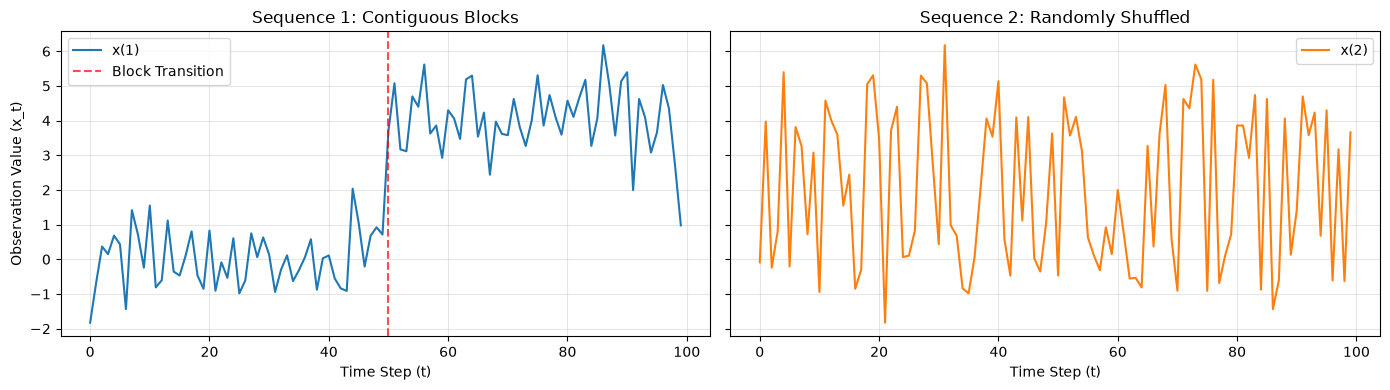


Comparison of Joint Feature Vectors Psi(x, z) in R^6:
Feature Name       | Sequence 1 (Contiguous) | Sequence 2 (Shuffled)  | Abs Difference 
--------------------------------------------------------------------------------
c_11 (1->1)        | 47.00                   | 25.00                  | 22.00          
c_12 (1->2)        | 3.00                    | 26.00                  | 23.00          
c_21 (2->1)        | 3.00                    | 25.00                  | 22.00          
c_22 (2->2)        | 46.00                   | 23.00                  | 23.00          
e_1 (sum x|z=1)    | 1.16                    | 1.16                   | 0.00           
e_2 (sum x|z=2)    | 201.98                  | 201.98                 | 0.00           


In [8]:
import matplotlib.pyplot as plt
import numpy as np



def compute_joint_features_sq8(x, z, K=2):
  """Computes joint feature map Psi(x, z) for scalar sequences.

  Returns a vector of dimension K^2 + K = 6:
  - First K^2 entries: transition counts c_ij
  - Last K entries: emission feature sums e_i
  """
  T = len(x)

  c = np.zeros((K, K))
  for t in range(1, T):
    c[z[t - 1] - 1, z[t] - 1] += 1


  e = np.zeros(K)
  for k in range(1, K + 1):
    e[k - 1] = np.sum(x[z == k])

  return np.concatenate([c.flatten(), e])


if __name__ == "__main__":
  np.random.seed(1405)
  T = 100

  # Part (a): Generate raw values (50 from N(0,1) and 50 from N(4,1))
  g0 = np.random.normal(0, 1, size=50)
  g1 = np.random.normal(4, 1, size=50)


  x1 = np.concatenate([g0, g1])


  x2 = x1.copy()
  np.random.shuffle(x2)


  print("=== Simulation Question 8: Toy Experiment Analysis ===")
  print(f"{'Statistic':<12} | {'Sequence 1 (Contiguous)':<23} | {'Sequence 2 (Shuffled)':<22}")
  print("-" * 65)
  print(f"{'Mean':<12} | {np.mean(x1):<23.4f} | {np.mean(x2):<22.4f}")
  print(f"{'Std Dev':<12} | {np.std(x1):<23.4f} | {np.std(x2):<22.4f}")
  print(f"{'Min':<12} | {np.min(x1):<23.4f} | {np.min(x2):<22.4f}")
  print(f"{'Max':<12} | {np.max(x1):<23.4f} | {np.max(x2):<22.4f}")
  print(f"{'Median':<12} | {np.median(x1):<23.4f} | {np.median(x2):<22.4f}")


  fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

  axes[0].plot(x1, color="tab:blue", lw=1.5, label="x(1)")
  axes[0].axvline(x=50, color="red", linestyle="--", alpha=0.7, label="Block Transition")
  axes[0].set_title("Sequence 1: Contiguous Blocks")
  axes[0].set_xlabel("Time Step (t)")
  axes[0].set_ylabel("Observation Value (x_t)")
  axes[0].grid(True, alpha=0.3)
  axes[0].legend()

  axes[1].plot(x2, color="tab:orange", lw=1.5, label="x(2)")
  axes[1].set_title("Sequence 2: Randomly Shuffled")
  axes[1].set_xlabel("Time Step (t)")
  axes[1].grid(True, alpha=0.3)
  axes[1].legend()

  plt.tight_layout()
  plt.show()

  #c
  z1 = np.where(x1 < 2.0, 1, 2)
  z2 = np.where(x2 < 2.0, 1, 2)


  psi1 = compute_joint_features_sq8(x1, z1, K=2)
  psi2 = compute_joint_features_sq8(x2, z2, K=2)

  # d
  feature_names = ["c_11 (1->1)", "c_12 (1->2)", "c_21 (2->1)", "c_22 (2->2)", "e_1 (sum x|z=1)", "e_2 (sum x|z=2)"]

  print("\n" + "=" * 65)
  print("Comparison of Joint Feature Vectors Psi(x, z) in R^6:")
  print("=" * 65)
  print(f"{'Feature Name':<18} | {'Sequence 1 (Contiguous)':<23} | {'Sequence 2 (Shuffled)':<22} | {'Abs Difference':<15}")
  print("-" * 80)
  for name, val1, val2 in zip(feature_names, psi1, psi2):
    diff = abs(val1 - val2)
    print(f"{name:<18} | {val1:<23.2f} | {val2:<22.2f} | {diff:<15.2f}")
  print("=" * 80)

=== Simulation Question 9: Feature Matrix Analysis ===
Feature Matrix Shape: (250, 6) (250 sequences x 6 features)


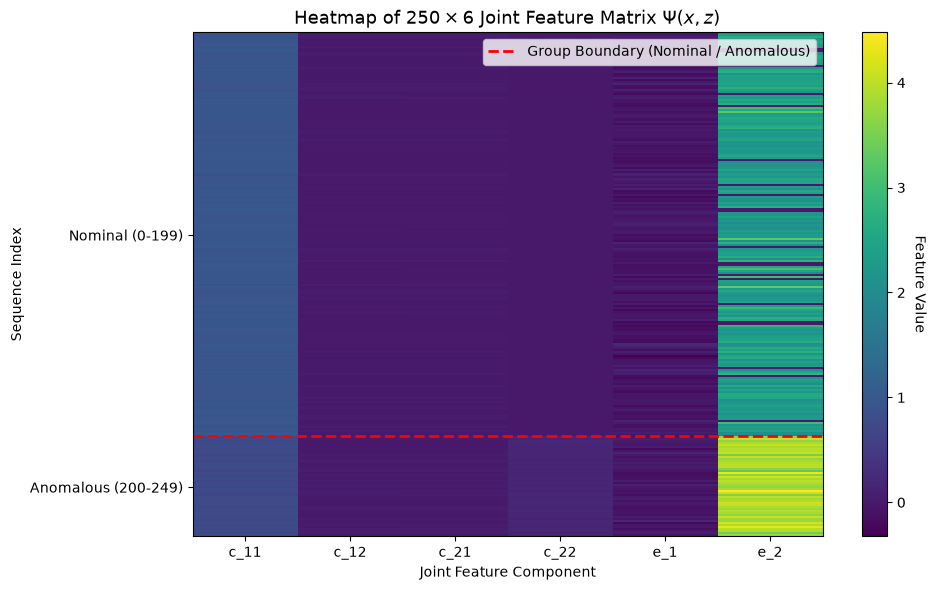


Feature    | Nominal Mean    | Anomalous Mean  | Abs Diff       
-----------------------------------------------------------------
c_11       | 0.9572          | 0.7491          | 0.2081         
c_12       | 0.0211          | 0.0343          | 0.0132         
c_21       | 0.0213          | 0.0341          | 0.0128         
c_22       | 0.0004          | 0.1824          | 0.1821         
e_1        | -0.0523         | -0.0337         | 0.0186         
e_2        | 2.1358          | 3.8907          | 1.7549         


In [9]:
import matplotlib.pyplot as plt
import numpy as np



def compute_joint_features(x, z, K=2, eps=1e-8):
  """Computes normalized joint feature vector Psi(x, z).

  - First K^2 entries: normalized transition counts c_ij / (T - 1)
  - Last K entries: per-state mean emissions sum(x|z=i) / (count(z=i) + eps)
  """
  T = len(x)

  c = np.zeros((K, K))
  for t in range(1, T):
    c[z[t - 1] - 1, z[t] - 1] += 1


  c_norm = c.flatten() / (T - 1)


  e = np.zeros(K)
  for k in range(1, K + 1):
    mask = z == k
    count = np.sum(mask)
    if count > 0:
      e[k - 1] = np.sum(x[mask]) / (count + eps)
    else:
      e[k - 1] = 0.0

  return np.concatenate([c_norm, e])


if __name__ == "__main__":
  # SQ 9 b): Dataset Generation (200 Nominal, 50 Anomalous)
  np.random.seed(1405)
  n_nom = 200
  n_anom = 50
  T = 100
  T_anom = 20
  mu_anom = 4.0

  X_nom = np.random.normal(0, 1, size=(n_nom, T))
  X_anom = np.random.normal(0, 1, size=(n_anom, T))

  for i in range(n_anom):
    start = np.random.randint(0, T - T_anom + 1)
    X_anom[i, start : start + T_anom] = np.random.normal(
        mu_anom, 1, size=T_anom
    )

  X_all = np.vstack([X_nom, X_anom])
  y_all = np.concatenate([np.zeros(n_nom, dtype=int), np.ones(n_anom, dtype=int)])

  #c
  features_list = []
  for i in range(len(X_all)):
    x_seq = X_all[i]
    z_seq = np.where(x_seq < 2.0, 1, 2)
    psi = compute_joint_features(x_seq, z_seq, K=2)
    features_list.append(psi)

  feature_matrix = np.array(features_list)
  feature_names = ["c_11", "c_12", "c_21", "c_22", "e_1", "e_2"]

  print("=== Simulation Question 9: Feature Matrix Analysis ===")
  print(f"Feature Matrix Shape: {feature_matrix.shape} (250 sequences x 6 features)")

  #plot
  plt.figure(figsize=(10, 6))
  plt.imshow(feature_matrix, aspect="auto", cmap="viridis", interpolation="none")
  cbar = plt.colorbar()
  cbar.set_label("Feature Value", rotation=270, labelpad=15)

  plt.yticks([100, 225], ["Nominal (0-199)", "Anomalous (200-249)"])
  plt.xticks(range(6), feature_names)
  plt.axhline(
      199.5,
      color="red",
      linewidth=2,
      linestyle="--",
      label="Group Boundary (Nominal / Anomalous)",
  )

  plt.title(
      r"Heatmap of $250 \times 6$ Joint Feature Matrix $\Psi(x, z)$",
      fontsize=13,
  )
  plt.xlabel("Joint Feature Component")
  plt.ylabel("Sequence Index")
  plt.legend(loc="upper right")
  plt.tight_layout()
  plt.savefig("Q9.png", dpi=300)
  plt.show()

  # print
  mean_nom = np.mean(feature_matrix[:200], axis=0)
  mean_anom = np.mean(feature_matrix[200:], axis=0)

  print("\n" + "=" * 65)
  print(
      f"{'Feature':<10} | {'Nominal Mean':<15} | {'Anomalous Mean':<15} |"
      f" {'Abs Diff':<15}"
  )
  print("-" * 65)
  for name, mn, ma in zip(feature_names, mean_nom, mean_anom):
    print(f"{name:<10} | {mn:<15.4f} | {ma:<15.4f} | {abs(mn - ma):<15.4f}")
  print("=" * 65)

Simulation Question 10 - simplified HMAD training on normal ECG5000 beats
iteration=1, changed=100.000%, mean_score=0.6573
iteration=2, changed=0.685%, mean_score=0.3501
Emission means: [-2.4556  0.1907]
Emission variances: [1.5563 0.4444]
Initial-state distribution: [0.7911 0.2089]
Transition matrix:
[[0.8921 0.1079]
 [0.0031 0.9969]]


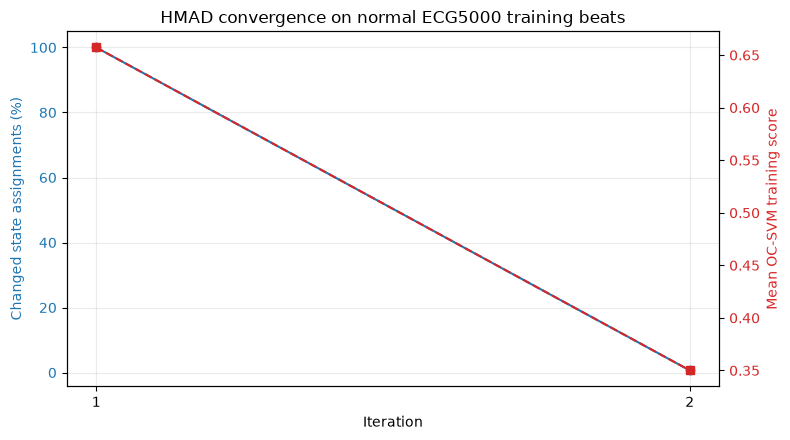

In [10]:
from pathlib import Path
import numpy as np
from ecg5000_hmad import (
    extract_features, fit_hmad, fit_ocsvm, fixed_contamination_cohorts,
    load_ecg5000, metrics_from_scores, score_hmad, score_ocsvm,
)

PROJECT_ROOT = Path.cwd()
PLOTS_DIR = PROJECT_ROOT / "Plots"
PLOTS_DIR.mkdir(exist_ok=True)
X_train, X_test, y_test, y_train_original, y_test_original = load_ecg5000(PROJECT_ROOT)

import matplotlib.pyplot as plt

hmad = fit_hmad(X_train, nu=0.1, max_iter=10, k=2)
history = hmad["history"]

print("Simulation Question 10 - simplified HMAD training on normal ECG5000 beats")
for row in history:
    print(f"iteration={row['iteration']}, changed={100*row['changed_fraction']:.3f}%, mean_score={row['mean_score']:.4f}")
print("Emission means:", np.round(hmad["means"], 4))
print("Emission variances:", np.round(hmad["variances"], 4))
print("Initial-state distribution:", np.round(hmad["pi"], 4))
print("Transition matrix:")
print(np.round(hmad["transition"], 4))

iterations = [row["iteration"] for row in history]
changed = [100 * row["changed_fraction"] for row in history]
mean_scores = [row["mean_score"] for row in history]
fig, axis_left = plt.subplots(figsize=(8, 4.5))
axis_left.plot(iterations, changed, "o-", color="tab:blue")
axis_left.set_xlabel("Iteration")
axis_left.set_ylabel("Changed state assignments (%)", color="tab:blue")
axis_left.tick_params(axis="y", labelcolor="tab:blue")
axis_left.set_xticks(iterations)
axis_left.grid(alpha=0.25)
axis_right = axis_left.twinx()
axis_right.plot(iterations, mean_scores, "s--", color="tab:red")
axis_right.set_ylabel("Mean OC-SVM training score", color="tab:red")
axis_right.tick_params(axis="y", labelcolor="tab:red")
plt.title("HMAD convergence on normal ECG5000 training beats")
fig.tight_layout()
fig.savefig(PLOTS_DIR / "Q10.png", dpi=300, bbox_inches="tight")
plt.show()


Simulation Question 11 - HMAD prediction on untouched official test split
roc_auc: 0.9577
precision: 0.8419
recall: 0.9466
f1: 0.8912
Trivial all-state-1 ROC-AUC: 0.5000


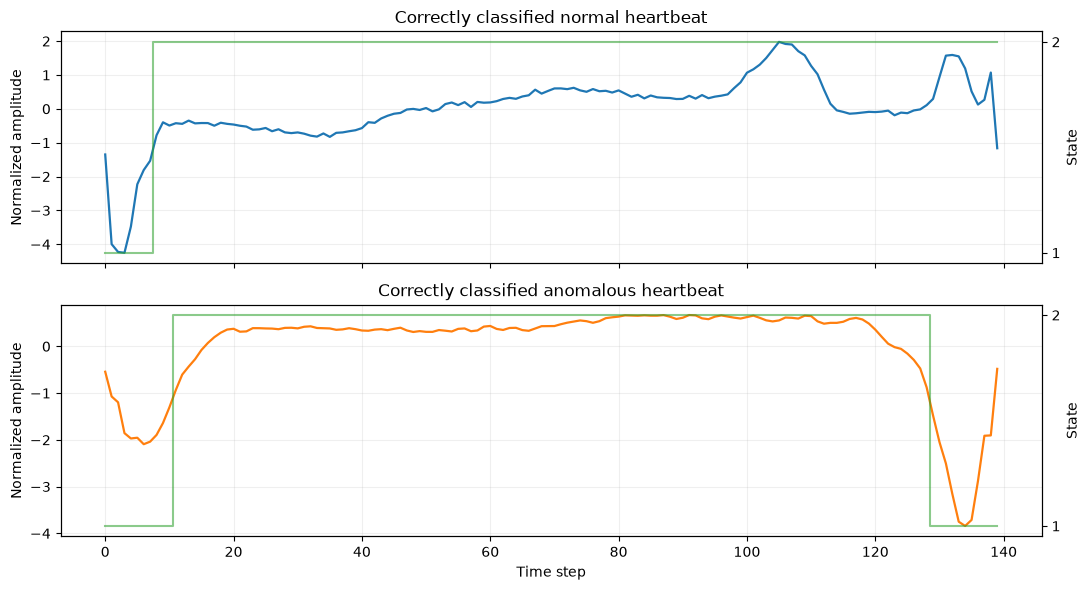

In [11]:
from pathlib import Path
import numpy as np
from ecg5000_hmad import (
    extract_features, fit_hmad, fit_ocsvm, fixed_contamination_cohorts,
    load_ecg5000, metrics_from_scores, score_hmad, score_ocsvm,
)

PROJECT_ROOT = Path.cwd()
PLOTS_DIR = PROJECT_ROOT / "Plots"
PLOTS_DIR.mkdir(exist_ok=True)
X_train, X_test, y_test, y_train_original, y_test_original = load_ecg5000(PROJECT_ROOT)

import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

hmad = fit_hmad(X_train, nu=0.1, max_iter=10, k=2)
hmad_scores, test_paths = score_hmad(X_test, hmad)
hmad_metrics = metrics_from_scores(y_test, hmad_scores)
trivial_scores, _ = score_hmad(X_test, hmad, trivial_states=True)
trivial_auc = roc_auc_score(y_test, -trivial_scores)

print("Simulation Question 11 - HMAD prediction on untouched official test split")
for name, value in hmad_metrics.items():
    print(f"{name}: {value:.4f}")
print(f"Trivial all-state-1 ROC-AUC: {trivial_auc:.4f}")

prediction = (hmad_scores < 0).astype(int)
normal_candidates = np.flatnonzero((y_test == 0) & (prediction == 0))
anomaly_candidates = np.flatnonzero((y_test == 1) & (prediction == 1))
normal_index, anomaly_index = normal_candidates[0], anomaly_candidates[0]
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for axis, index, title, color in (
    (axes[0], normal_index, "Correctly classified normal heartbeat", "tab:blue"),
    (axes[1], anomaly_index, "Correctly classified anomalous heartbeat", "tab:orange"),
):
    axis.plot(X_test[index], color=color, lw=1.6, label="ECG")
    twin = axis.twinx()
    twin.step(np.arange(X_test.shape[1]), test_paths[index] + 1, where="mid", color="tab:green", alpha=0.55, label="Viterbi state")
    twin.set_yticks([1, 2])
    twin.set_ylabel("State")
    axis.set_ylabel("Normalized amplitude")
    axis.set_title(title)
    axis.grid(alpha=0.2)
axes[-1].set_xlabel("Time step")
fig.tight_layout()
fig.savefig(PLOTS_DIR / "Q11.png", dpi=300, bbox_inches="tight")
plt.show()


student delivarable

In [12]:
"""HMAD: Hidden Markov Anomaly Detector (Student Deliverable Module)

Self-contained programmatic pseudocode implementation of HMAD. Includes:
1. Training Procedure: Alternating Viterbi state inference, OC-SVM fitting, and HMM parameter updating (Algorithm 1).
2. Prediction Procedure Pipeline: Viterbi decoding of test sequences -> Joint feature extraction -> OC-SVM scoring.
"""

import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM


class HMADClassifier:
  """Hidden Markov Anomaly Detector (HMAD)

  Combines Gaussian Hidden Markov Models (HMM) for latent sequence structure
  decoding with One-Class SVM (OC-SVM) for boundary estimation in feature space R^(K^2 + K).
  """

  def __init__(self, n_states=2, nu=0.1, max_iter=10, random_state=1405):
    self.K = n_states
    self.nu = nu
    self.max_iter = max_iter
    self.random_state = random_state

    # Fitted model parameters
    self.pi = None
    self.A = None
    self.means = None
    self.vars = None
    self.scaler = StandardScaler()
    self.oc_svm = OneClassSVM(kernel="rbf", gamma="scale", nu=self.nu)

  def _viterbi_decode(self, x):
    """Step 1 of Prediction & Training: Log-space Viterbi decoding."""
    T = len(x)
    K = self.K
    log_pi = np.log(np.maximum(self.pi, 1e-12))
    log_A = np.log(np.maximum(self.A, 1e-12))

    def log_emission(val, m, v):
      v = max(v, 1e-6)
      return -0.5 * np.log(2 * np.pi * v) - ((val - m) ** 2) / (2 * v)

    delta = np.zeros((T, K))
    psi = np.zeros((T, K), dtype=int)

    for j in range(K):
      delta[0, j] = log_pi[j] + log_emission(x[0], self.means[j], self.vars[j])

    for t in range(1, T):
      for j in range(K):
        temp = delta[t - 1, :] + log_A[:, j]
        psi[t, j] = np.argmax(temp)
        delta[t, j] = (
            np.max(temp) + log_emission(x[t], self.means[j], self.vars[j])
        )

    z_star = np.zeros(T, dtype=int)
    z_star[-1] = np.argmax(delta[-1, :]) + 1

    for t in range(T - 2, -1, -1):
      z_star[t] = psi[t + 1, z_star[t + 1] - 1] + 1

    return z_star

  def _compute_joint_features(self, x, z):
    """Computes joint feature mapping Psi(x, z) in R^(K^2 + K)."""
    T = len(x)
    K = self.K

    # Transition features c_ij / (T - 1)
    c = np.zeros((K, K))
    for t in range(1, T):
      c[z[t - 1] - 1, z[t] - 1] += 1
    c_norm = c.flatten() / (T - 1)


    e = np.zeros(K)
    for k in range(1, K + 1):
      mask = z == k
      count = np.sum(mask)
      e[k - 1] = np.sum(x[mask]) / (count + 1e-8) if count > 0 else 0.0

    return np.concatenate([c_norm, e])

  def fit(self, X_train):
    """ALGORITHM 1: HMAD Training Procedure

    Input: Nominal sequence matrix X_train of shape (N, T)
    """
    N, T = X_train.shape


    pooled_obs = X_train.flatten().reshape(-1, 1)
    kmeans = KMeans(
        n_clusters=self.K, random_state=self.random_state, n_init=10
    ).fit(pooled_obs)
    sorted_idx = np.argsort(kmeans.cluster_centers_.flatten())

    self.means = kmeans.cluster_centers_.flatten()[sorted_idx].copy()
    labels = kmeans.labels_
    self.vars = np.array(
        [np.var(pooled_obs[labels == sorted_idx[k]]) for k in range(self.K)]
    )

    self.A = np.array([[0.9, 0.1], [0.1, 0.9]])
    self.pi = np.array([0.5, 0.5])


    prev_z = None
    for iteration in range(self.max_iter):

      current_z = []
      psi_matrix = []
      for i in range(N):
        z_i = self._viterbi_decode(X_train[i])
        psi_i = self._compute_joint_features(X_train[i], z_i)
        current_z.append(z_i)
        psi_matrix.append(psi_i)

      current_z = np.array(current_z)
      psi_matrix = np.array(psi_matrix)


      psi_scaled = self.scaler.fit_transform(psi_matrix)
      self.oc_svm.fit(psi_scaled)


      for k in range(self.K):
        mask = current_z == (k + 1)
        obs_k = X_train[mask]
        if len(obs_k) > 0:
          self.means[k] = np.mean(obs_k)
          self.vars[k] = np.var(obs_k) + 1e-6

      c_mat = np.zeros((self.K, self.K))
      for i in range(N):
        for t in range(1, T):
          c_mat[current_z[i, t - 1] - 1, current_z[i, t] - 1] += 1
      self.A = c_mat / np.maximum(c_mat.sum(axis=1, keepdims=True), 1e-8)

      # Convergence Check
      if prev_z is not None and np.mean(current_z != prev_z) < 0.01:
        break
      prev_z = current_z.copy()

    return self

  def decision_function(self, X_test):
    """PREDICTION PIPELINE: Score test sequences

    Input: Test sequence matrix X_test of shape (N_test, T)
    Output: OC-SVM decision scores f(x) (positive = nominal, negative = anomaly)
    """
    N_test = len(X_test)
    psi_test_matrix = []

    for i in range(N_test):

      z_star = self._viterbi_decode(X_test[i])


      psi_test = self._compute_joint_features(X_test[i], z_star)
      psi_test_matrix.append(psi_test)


    psi_test_matrix = np.array(psi_test_matrix)
    psi_scaled = self.scaler.transform(psi_test_matrix)

    return self.oc_svm.decision_function(psi_scaled)

  def predict(self, X_test):
    """Predict binary anomaly labels (1 for anomaly, 0 for nominal)."""
    scores = self.decision_function(X_test)
    return np.where(scores < 0, 1, 0)

6.1

In [13]:
from pathlib import Path
import numpy as np
from ecg5000_hmad import (
    extract_features, fit_hmad, fit_ocsvm, fixed_contamination_cohorts,
    load_ecg5000, metrics_from_scores, score_hmad, score_ocsvm,
)

PROJECT_ROOT = Path.cwd()
PLOTS_DIR = PROJECT_ROOT / "Plots"
PLOTS_DIR.mkdir(exist_ok=True)
X_train, X_test, y_test, y_train_original, y_test_original = load_ecg5000(PROJECT_ROOT)

from collections import Counter
import hashlib

archive = PROJECT_ROOT / "data" / "ECG5000" / "ECG5000.zip"
checksum = hashlib.sha256(archive.read_bytes()).hexdigest().upper()
print("Section 6.1 - ECG5000 dataset verification")
print("Source: UCR/TSML ECG5000; derived from PhysioNet BIDMC CHF record chf07")
print("One sequence: one physiologically segmented, interpolated heartbeat")
print("Original TRAIN class counts:", dict(sorted(Counter(y_train_original).items())))
print("Original TEST class counts:", dict(sorted(Counter(y_test_original).items())))
print("One-class train shape:", X_train.shape)
print("Untouched test shape:", X_test.shape)
print("Binary test counts: normal=", int(np.sum(y_test == 0)), " anomaly=", int(np.sum(y_test == 1)))
print("Training time steps:", X_train.size)
print("Missing values:", int(np.isnan(X_train).sum() + np.isnan(X_test).sum()))
print("Sequence length distribution: min=median=max=", X_train.shape[1])
print("Archive SHA-256:", checksum)


Section 6.1 - ECG5000 dataset verification
Source: UCR/TSML ECG5000; derived from PhysioNet BIDMC CHF record chf07
One sequence: one physiologically segmented, interpolated heartbeat
Original TRAIN class counts: {np.int64(1): 292, np.int64(2): 177, np.int64(3): 10, np.int64(4): 19, np.int64(5): 2}
Original TEST class counts: {np.int64(1): 2627, np.int64(2): 1590, np.int64(3): 86, np.int64(4): 175, np.int64(5): 22}
One-class train shape: (292, 140)
Untouched test shape: (4500, 140)
Binary test counts: normal= 2627  anomaly= 1873
Training time steps: 40880
Missing values: 0
Sequence length distribution: min=median=max= 140
Archive SHA-256: 41F6DE20AC895E9CE31753860995518951F1ED42A405D0E51C909D27E3B3C5A4


In [14]:
from pathlib import Path
import numpy as np
from ecg5000_hmad import (
    extract_features, fit_hmad, fit_ocsvm, fixed_contamination_cohorts,
    load_ecg5000, metrics_from_scores, score_hmad, score_ocsvm,
)

PROJECT_ROOT = Path.cwd()
PLOTS_DIR = PROJECT_ROOT / "Plots"
PLOTS_DIR.mkdir(exist_ok=True)
X_train, X_test, y_test, y_train_original, y_test_original = load_ecg5000(PROJECT_ROOT)

import time
from sklearn.preprocessing import StandardScaler

phi_train = extract_features(X_train, "flattened")
phi_test = extract_features(X_test, "flattened")
scaler = StandardScaler().fit(phi_train)
scaled_train = scaler.transform(phi_train)
scaled_test = scaler.transform(phi_test)
print("Section 6.2 - leak-free preprocessing")
print("Scaler fitted only on normal TRAIN sequences")
print("Post-scale train feature mean range:", float(scaled_train.mean(0).min()), float(scaled_train.mean(0).max()))
print("Post-scale train feature std range:", float(scaled_train.std(0).min()), float(scaled_train.std(0).max()))

start = time.perf_counter()
baseline = fit_ocsvm(X_train, "flattened", nu=0.1)
_ = score_ocsvm(X_test, baseline)
baseline_seconds = time.perf_counter() - start
start = time.perf_counter()
hmad = fit_hmad(X_train, nu=0.1, max_iter=10, k=2)
_ = score_hmad(X_test, hmad)
hmad_seconds = time.perf_counter() - start
print(f"OC-SVM fit+score runtime: {baseline_seconds:.3f} s")
print(f"HMAD fit+Viterbi test-score runtime: {hmad_seconds:.3f} s")


Section 6.2 - leak-free preprocessing
Scaler fitted only on normal TRAIN sequences


Post-scale train feature mean range: -3.1162287362423916e-15 2.8869600773900047e-15
Post-scale train feature std range: 0.9999999999999987 1.0000000000000009


OC-SVM fit+score runtime: 0.061 s
HMAD fit+Viterbi test-score runtime: 9.862 s


Section 6.3 - primary untouched official test results
OC-SVM Flattened {'roc_auc': 0.984, 'precision': 0.8314, 'recall': 0.9979, 'f1': 0.9071}
OC-SVM Summary {'roc_auc': 0.9518, 'precision': 0.8124, 'recall': 0.9274, 'f1': 0.8661}
OC-SVM Window {'roc_auc': 0.9823, 'precision': 0.8319, 'recall': 0.9984, 'f1': 0.9075}
HMAD {'roc_auc': 0.9577, 'precision': 0.8419, 'recall': 0.9466, 'f1': 0.8912}


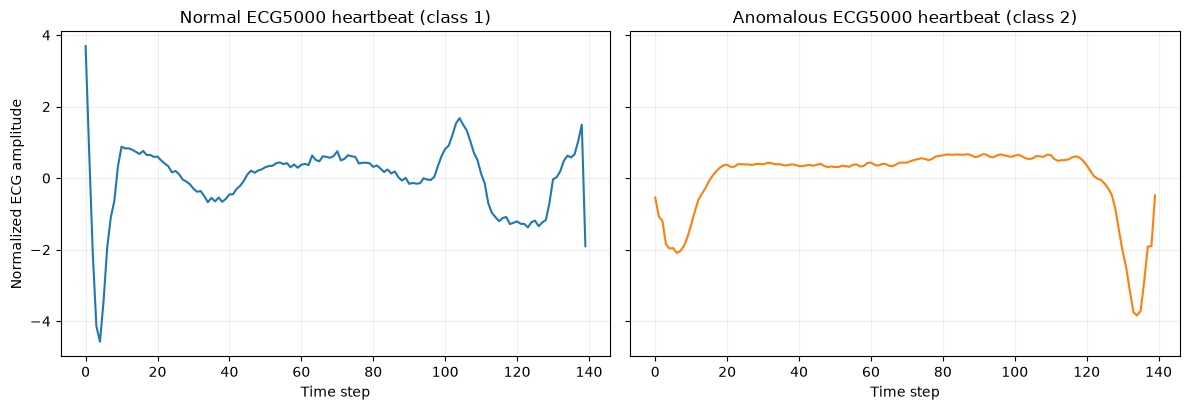

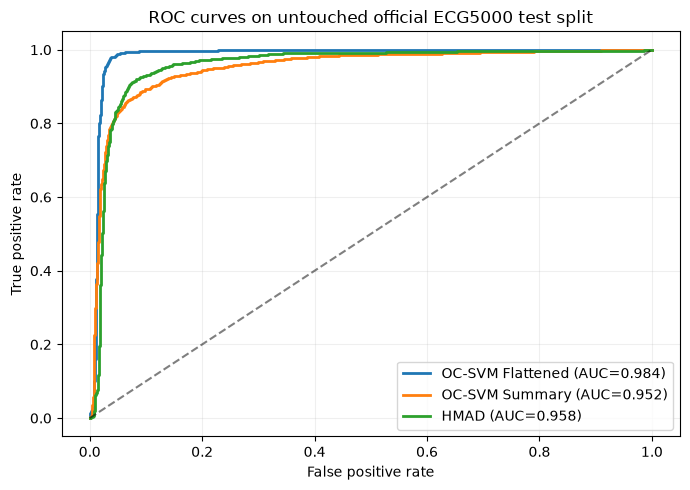

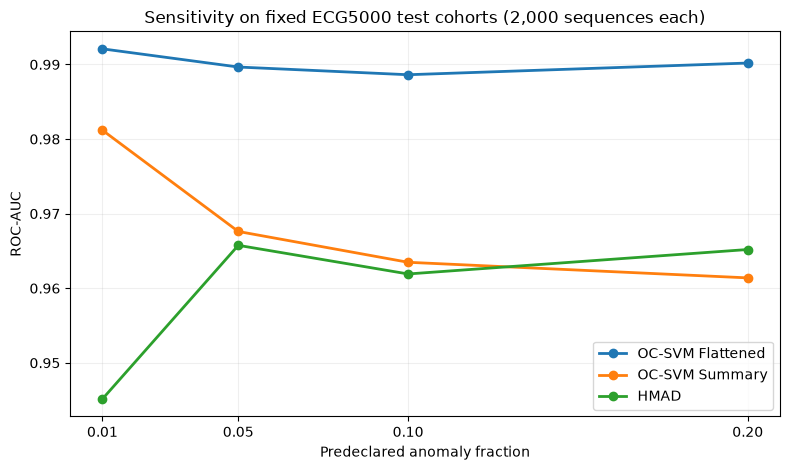

1347

In [15]:
from pathlib import Path
import numpy as np
from ecg5000_hmad import (
    extract_features, fit_hmad, fit_ocsvm, fixed_contamination_cohorts,
    load_ecg5000, metrics_from_scores, score_hmad, score_ocsvm,
)

PROJECT_ROOT = Path.cwd()
PLOTS_DIR = PROJECT_ROOT / "Plots"
PLOTS_DIR.mkdir(exist_ok=True)
X_train, X_test, y_test, y_train_original, y_test_original = load_ecg5000(PROJECT_ROOT)

import json
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

models = {
    "OC-SVM Flattened": fit_ocsvm(X_train, "flattened", 0.1),
    "OC-SVM Summary": fit_ocsvm(X_train, "summary", 0.1),
    "OC-SVM Window": fit_ocsvm(X_train, "window", 0.1),
}
scores = {name: score_ocsvm(X_test, model) for name, model in models.items()}
hmad = fit_hmad(X_train, nu=0.1, max_iter=10, k=2)
scores["HMAD"] = score_hmad(X_test, hmad)[0]
primary_results = {name: metrics_from_scores(y_test, value) for name, value in scores.items()}

print("Section 6.3 - primary untouched official test results")
for name, result in primary_results.items():
    print(name, {key: round(value, 4) for key, value in result.items()})

normal_index = np.flatnonzero(y_test == 0)[0]
anomaly_index = np.flatnonzero(y_test == 1)[0]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
axes[0].plot(X_test[normal_index], color="tab:blue")
axes[0].set_title("Normal ECG5000 heartbeat (class 1)")
axes[1].plot(X_test[anomaly_index], color="tab:orange")
axes[1].set_title(f"Anomalous ECG5000 heartbeat (class {y_test_original[anomaly_index]})")
for axis in axes:
    axis.set_xlabel("Time step")
    axis.grid(alpha=0.2)
axes[0].set_ylabel("Normalized ECG amplitude")
fig.tight_layout()
fig.savefig(PLOTS_DIR / "6_4_a.png", dpi=300, bbox_inches="tight")
plt.show()

fig, axis = plt.subplots(figsize=(7, 5))
for name in ("OC-SVM Flattened", "OC-SVM Summary", "HMAD"):
    fpr, tpr, _ = roc_curve(y_test, -scores[name])
    axis.plot(fpr, tpr, lw=2, label=f"{name} (AUC={primary_results[name]['roc_auc']:.3f})")
axis.plot([0, 1], [0, 1], "k--", alpha=0.5)
axis.set(xlabel="False positive rate", ylabel="True positive rate", title="ROC curves on untouched official ECG5000 test split")
axis.grid(alpha=0.2)
axis.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / "6_4_b.png", dpi=300, bbox_inches="tight")
plt.show()

cohorts = fixed_contamination_cohorts(y_test)
sensitivity = {name: [] for name in scores}
for fraction, indices in cohorts.items():
    for name, value in scores.items():
        sensitivity[name].append(metrics_from_scores(y_test[indices], value[indices])["roc_auc"])
fig, axis = plt.subplots(figsize=(8, 4.8))
for name in ("OC-SVM Flattened", "OC-SVM Summary", "HMAD"):
    axis.plot(list(cohorts), sensitivity[name], marker="o", lw=2, label=name)
axis.set(xlabel="Predeclared anomaly fraction", ylabel="ROC-AUC", title="Sensitivity on fixed ECG5000 test cohorts (2,000 sequences each)")
axis.set_xticks(list(cohorts))
axis.grid(alpha=0.2)
axis.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / "6_4_c.png", dpi=300, bbox_inches="tight")
plt.show()

serializable = {"primary": primary_results, "sensitivity": {name: dict(zip(map(str, cohorts), values)) for name, values in sensitivity.items()}}
(PROJECT_ROOT / "results_ecg5000.json").write_text(json.dumps(serializable, indent=2), encoding="utf-8")


In [16]:
from pathlib import Path
import numpy as np
from ecg5000_hmad import (
    extract_features, fit_hmad, fit_ocsvm, fixed_contamination_cohorts,
    load_ecg5000, metrics_from_scores, score_hmad, score_ocsvm,
)

PROJECT_ROOT = Path.cwd()
PLOTS_DIR = PROJECT_ROOT / "Plots"
PLOTS_DIR.mkdir(exist_ok=True)
X_train, X_test, y_test, y_train_original, y_test_original = load_ecg5000(PROJECT_ROOT)

import time

print("Section 6.4 - OC-SVM representation benchmark on the untouched test split")
print(f"{'Representation':<12} {'Dim':>5} {'ROC-AUC':>9} {'Precision':>10} {'Recall':>9} {'F1':>9} {'Seconds':>9}")
for representation in ("flattened", "summary", "window"):
    start = time.perf_counter()
    fitted = fit_ocsvm(X_train, representation, nu=0.1)
    values = score_ocsvm(X_test, fitted)
    elapsed = time.perf_counter() - start
    result = metrics_from_scores(y_test, values)
    dim = extract_features(X_train, representation).shape[1]
    print(f"{representation:<12} {dim:>5} {result['roc_auc']:>9.4f} {result['precision']:>10.4f} {result['recall']:>9.4f} {result['f1']:>9.4f} {elapsed:>9.4f}")


Section 6.4 - OC-SVM representation benchmark on the untouched test split
Representation   Dim   ROC-AUC  Precision    Recall        F1   Seconds
flattened      140    0.9840     0.8314    0.9979    0.9071    0.0814
summary          5    0.9518     0.8124    0.9274    0.8661    0.0622


window          20    0.9823     0.8319    0.9984    0.9075    0.0492
